### Assignment 1 - Markov Chain Monte Carlo

In [31]:
# Imports
import numpy as np
from matplotlib import pyplot as plt

#### Excercise 1 - 2D Ising Model

##### Part 1 - Ising Model Definition

In [ ]:
def random_selection(
        x: int, 
        y: int, 
        L: int,
) -> tuple[int, int]:
    """
    x: Row position of the last sampled node
    y: Columnn position of the last sampled node
    L: Length of the lattice

    Return a randomly selected node (x, y)
    """
    return int(np.random.randint(0, L)), int(np.random.randint(0, L))

def sequential_selection(
        x: int,
        y: int,
        L: int,
) -> tuple[int, int]:
    """
    x: Row position of the last sampled node
    y: Column position of the last sampled node
    L: Length of the lattice

    Return the next node in a snake like fashion
    """
    # If we reach the end reset
    if x % 2 == 0 and y+1 == L and x+1 == L:
        return (0, 0)
    if x % 2 != 0 and y-1 == -1 and x+1 == L:
        return (0, 0)
    # If we reach the end of an odd row step down
    if x % 2 == 0 and y+1 == L:
        return (x+1, y)
    # If we reach the start of an even row step down
    if x % 2 != 0 and y-1 == -1:
        return (x+1, y)
    # If we are in an odd row step right
    if x % 2 == 0:
        return (x, y+1)
    # If we are in an even row step left
    return (x, y-1)


In [96]:
def sample_configurations(
     L: int,
     J: float,
     h: float,
     T: float,
     mcs_max: int = 1000,
     selection_method: str = "sequential",

) -> tuple[list[int], list[int], np.array]:
    """
       Inputs
          L: Side length of the lattice
          J: Interaction parameter
          h: External field strength
          T: Temperature
          mcs_max: Maximum number of MC steps to run
          selection_method: Method for selecting which node's spin to flip next

        Outputs
           energies: history of energies for each configuration
           magnetizations: history magnetizations for each configuration
           lattice: last lattice configuration sampled

       Run Metropolis-Hastings Algorithm to sample a lattice spin configuration
       according to the Boltzmann distribution defined by the model's parameters.
    """
    # Validate inputs
    assert selection_method in ("sequential", "random")
    select_fn = sequential_selection if selection_method == "sequential" else random_selection
    # Initialize the lattice and starting node
    lattice = np.ones((L, L))
    x, y = 0, 0
    # Compute initial energy and magnetization
    E0 = -2 * J * L**2 - h * L**2
    m0 = 1
    # Initialize energy and magnetization history
    energies = [E0,]
    magnetizations = [m0,]
    for t in range(mcs_max * L**2):
        # Select the node whose spin to flip
        x, y = select_fn(x, y, L)
        # Compute the energy difference
        rows = [(x+dx) % L for dx, dy in ((1,0),(0,1),(-1,0),(0,-1))]
        cols = [(y+dy) % L for dx, dy in ((1,0),(0,1),(-1,0),(0,-1))]
        S = np.sum(lattice[rows, cols])
        dE = 2 * lattice[x, y] * (J * S + h)
        # Determine whether to accept the proposal or not
        p = min(1.0, np.exp(-1.0*dE / T))
        if np.random.random() < p:
            lattice[x, y] *= -1
            # Update energy and magnetization
            energies.append(energies[-1] + dE)
            magnetizations.append(magnetizations[-1] + (2 * lattice[x, y] / L**2))
        else:
            energies.append(energies[-1])
            magnetizations.append(magnetizations[-1])
    # Downsample the energies and magnetizations to per mcs step values
    E_per_mcs = np.array(energies[1:])[L**2-1::L**2]
    m_per_mcs = np.array(magnetizations[1:])[L**2-1::L**2]
    return E_per_mcs, m_per_mcs, lattice

##### Part 2 - Determine stability and convergence

**Experiment 1** - High Temperature Domain

In this domain, entropy dominates so the system converges to $m=0$ with random thermal fluctuations. 

In [99]:
E, m, lattice = sample_configurations(
    L=10,
    J = 1,
    h = 0,
    T = 3.0
)

burn_in = 100

print(f"Energy")
print(f"mean: {np.mean(E[burn_in:])}    std: {np.std(E[burn_in:])}")
print()
print(f"Magnetization")
print(f"mean: {np.mean(m[burn_in:])}    std: {np.std(m[burn_in:])}")

Energy
mean: -82.4888888888889    std: 19.18682675659668

Magnetization
mean: -0.045222222222222844    std: 0.33082230133672735


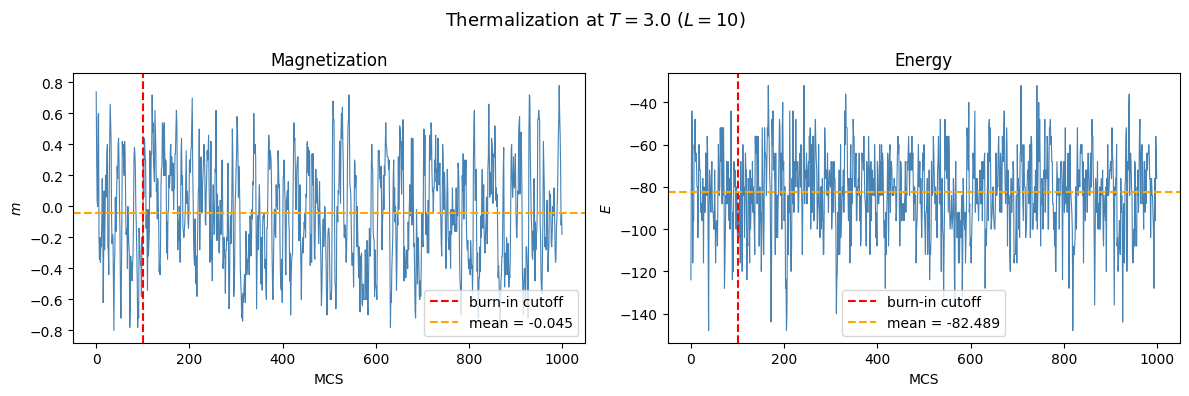

In [100]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(m, color='steelblue', lw=0.8)
ax1.axvline(burn_in, color='red', linestyle='--', label='burn-in cutoff')
ax1.axhline(np.mean(m[burn_in:]), color='orange', linestyle='--', label=f'mean = {np.mean(m[burn_in:]):.3f}')
ax1.set_xlabel('MCS')
ax1.set_ylabel('$m$')
ax1.set_title('Magnetization')
ax1.legend()

ax2.plot(E, color='steelblue', lw=0.8)
ax2.axvline(burn_in, color='red', linestyle='--', label='burn-in cutoff')
ax2.axhline(np.mean(E[burn_in:]), color='orange', linestyle='--', label=f'mean = {np.mean(E[burn_in:]):.3f}')
ax2.set_xlabel('MCS')
ax2.set_ylabel('$E$')
ax2.set_title('Energy')
ax2.legend()

plt.suptitle(f'Thermalization at $T = 3.0$ ($L = 10$)', fontsize=13)
plt.tight_layout()

**Experiment 2** - Low Temperature Domain

In this domain, free energy minimization dominates so the system converges to $m=1$, immediately because the initial state has all spins aligned +1.

In [103]:
E, m, lattice = sample_configurations(
    L=10,
    J = 1,
    h = 0,
    T = 1.0
)

burn_in = 25

print(f"Energy")
print(f"mean: {np.mean(E[burn_in:])}    std: {np.std(E[burn_in:])}")
print()
print(f"Magnetization")
print(f"mean: {np.mean(m[burn_in:])}    std: {np.std(m[burn_in:])}")

Energy
mean: -199.69641025641025    std: 1.5604527403182067

Magnetization
mean: 0.9992205128205128    std: 0.004077152065815596


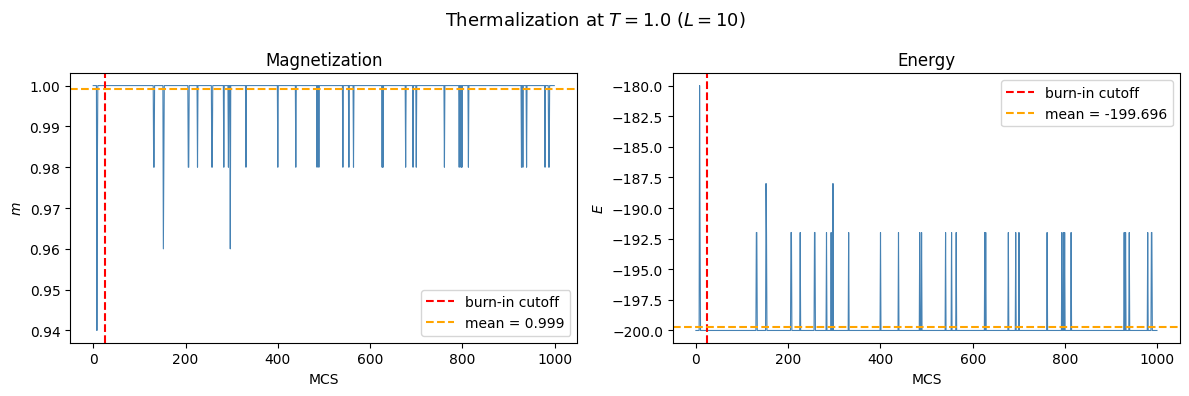

In [104]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(m, color='steelblue', lw=0.8)
ax1.axvline(burn_in, color='red', linestyle='--', label='burn-in cutoff')
ax1.axhline(np.mean(m[burn_in:]), color='orange', linestyle='--', label=f'mean = {np.mean(m[burn_in:]):.3f}')
ax1.set_xlabel('MCS')
ax1.set_ylabel('$m$')
ax1.set_title('Magnetization')
ax1.legend()

ax2.plot(E, color='steelblue', lw=0.8)
ax2.axvline(burn_in, color='red', linestyle='--', label='burn-in cutoff')
ax2.axhline(np.mean(E[burn_in:]), color='orange', linestyle='--', label=f'mean = {np.mean(E[burn_in:]):.3f}')
ax2.set_xlabel('MCS')
ax2.set_ylabel('$E$')
ax2.set_title('Energy')
ax2.legend()

plt.suptitle(f'Thermalization at $T = 1.0$ ($L = 10$)', fontsize=13)
plt.tight_layout()

##### Part 3 - Experiments for varying $T$ and $L$

**Varying $T$**

Concentrate samples around the critical temperature $T = 2.27$

In [106]:
temperatures = np.concatenate([
    np.linspace(0.5, 1.5, 4),
    np.linspace(1.5, 3.0, 12),
    np.linspace(3.0, 4.0, 4)
])

Run the experiments

In [109]:
mcs_max = 500
burn_in = 100
n_reps = 10
L = 10

mean_magnetizations = []
std_magnetizations = []

for T in temperatures:
    rep_magnetizations = []
    for _ in range(n_reps):
        E, m, lattice = sample_configurations(
            L=L,
            J=1.0,
            h=0.0,
            T=T,
            mcs_max=mcs_max,
        )
        # Discard burn-in and record equilibrium mean
        rep_magnetizations.append(np.mean(np.abs(m[burn_in:])))
    mean_magnetizations.append(np.mean(rep_magnetizations))
    std_magnetizations.append(np.std(rep_magnetizations))

mean_magnetizations = np.array(mean_magnetizations)
std_magnetizations = np.array(std_magnetizations)

$m$ vs $T$ plot

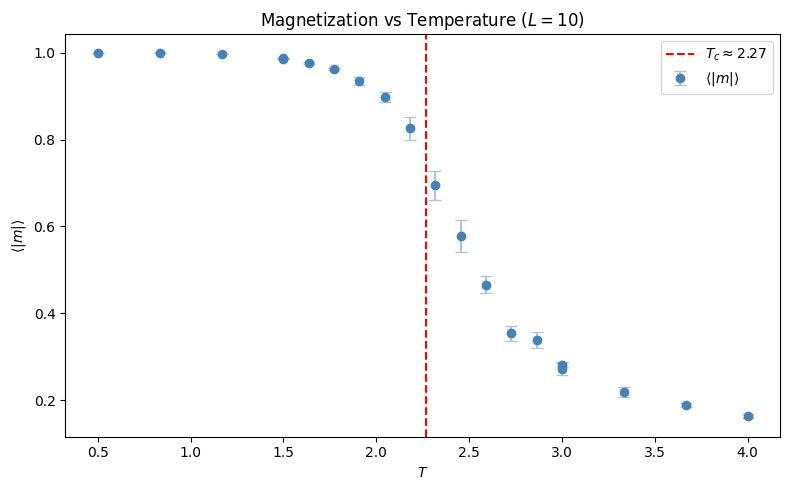

In [110]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    temperatures,
    mean_magnetizations,
    yerr=std_magnetizations,
    fmt='o',
    capsize=4,
    color='steelblue',
    ecolor='lightsteelblue',
    label='$\\langle |m| \\rangle$'
)
ax.axvline(2.27, color='red', linestyle='--', label='$T_c \\approx 2.27$')
ax.set_xlabel('$T$')
ax.set_ylabel('$\\langle |m| \\rangle$')
ax.set_title(f'Magnetization vs Temperature ($L = {L}$)')
ax.legend()
plt.tight_layout()

This demonstrates the two temperature domains that we saw in Step 2. It also shows the phase transition between them. During the phase transition, the error bars are greatest because of the "critical slowing" affect near the critical temperature where the MCMC convergence slows.

**Varying $L$**

Run the experiments

In [111]:
L_values = [5, 10, 20, 40]
mcs_max = 300
burn_in = 100
n_reps = 5

results = {}

for L in L_values:
    print(f"Running L={L}...")
    mean_magnetizations = []
    std_magnetizations = []
    for T in temperatures:
        rep_magnetizations = []
        for _ in range(n_reps):
            E, m, lattice = sample_configurations(
                L=L,
                J=1.0,
                h=0.0,
                T=T,
                mcs_max=mcs_max,
            )
            rep_magnetizations.append(np.mean(np.abs(m[burn_in:])))
        mean_magnetizations.append(np.mean(rep_magnetizations))
        std_magnetizations.append(np.std(rep_magnetizations))
    results[L] = {
        'mean': np.array(mean_magnetizations),
        'std': np.array(std_magnetizations)
    }

Running L=5...
Running L=10...
Running L=20...
Running L=40...
Done.


$m$ vs $L$ plot

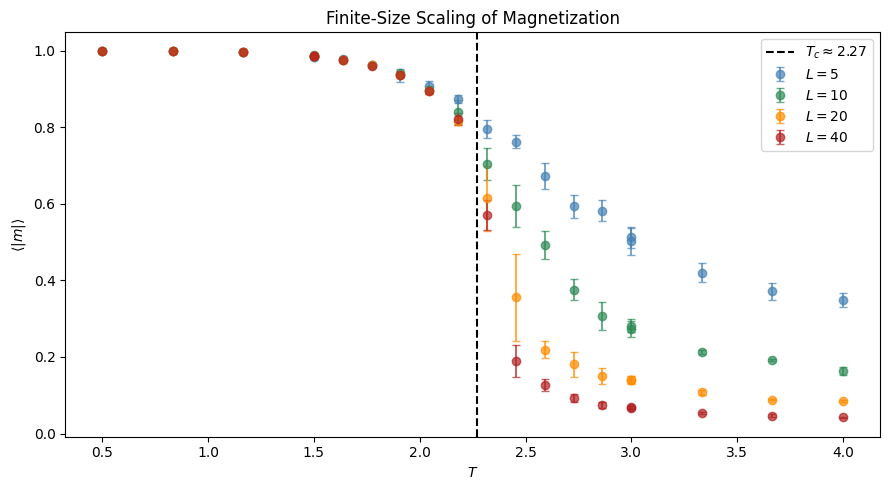

In [112]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['steelblue', 'seagreen', 'darkorange', 'firebrick']

for (L, color) in zip(L_values, colors):
    ax.errorbar(
        temperatures,
        results[L]['mean'],
        yerr=results[L]['std'],
        fmt='o',
        capsize=3,
        color=color,
        ecolor=color,
        alpha=0.7,
        label=f'$L = {L}$'
    )

ax.axvline(2.27, color='black', linestyle='--', label='$T_c \\approx 2.27$')
ax.set_xlabel('$T$')
ax.set_ylabel('$\\langle |m| \\rangle$')
ax.set_title('Finite-Size Scaling of Magnetization')
ax.legend()
plt.tight_layout()

This shows the role of boundary effects. Theoretically, we know that as $L\rightarrow\infty$ the transition becomes infinitely sharp because this is a second-order transition (discontinous derivative). Emperically, we see that the transition is sharper as the size of the lattice is increased. Again we also see the variance is largest near the critical temperature.

##### Part 4 - Configuration plots vs $T$

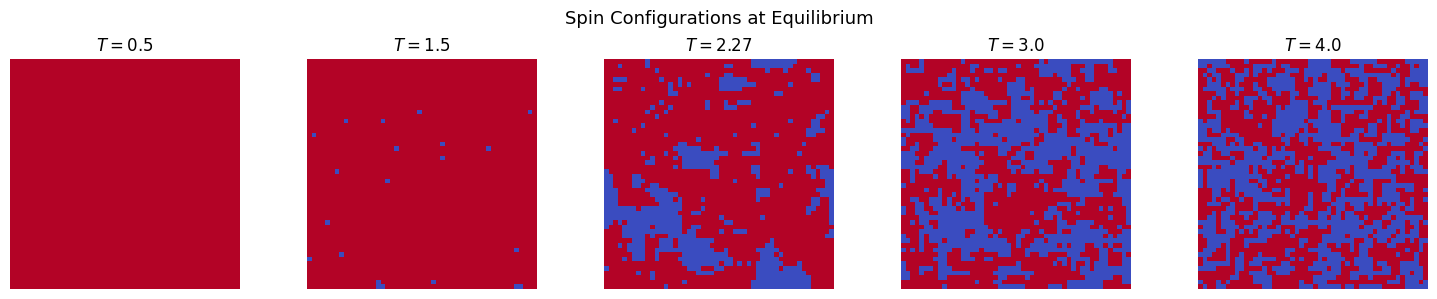

In [114]:
snapshot_temperatures = [0.5, 1.5, 2.27, 3.0, 4.0]

fig, axes = plt.subplots(1, len(snapshot_temperatures), figsize=(15, 3))

for ax, T in zip(axes, snapshot_temperatures):
    _, _, lattice = sample_configurations(
        L=50,
        J=1.0,
        h=0.0,
        T=T,
        mcs_max=500,
    )
    ax.imshow(lattice, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_title(f'$T = {T}$')
    ax.axis('off')

plt.suptitle('Spin Configurations at Equilibrium', fontsize=13)
plt.tight_layout()

This visually shows how entropy increases with temperature. Below the critical temperature, the system strongly prefers to minimize its free entropy (all up-spins, red). Once temperature is increased past the critical temperature, the system under goes a phase transition in which the system disorders (random mix of spins, red and blue). 

#### Excercise 2 - Potts Model

##### Step 1 - Proposal Rule

The proposal rule must satisfy the irreducible property, any state can be reached from any other state in a finite number of steps, in order for the MDP to satisfy the ergodic property, the foundation on which MCMC is built.<br/><br/>

A simple rule that satisfies the irreducible property
1. Pick a random node
2. Sample a new spin<br/><br/>

This is a generalization of the Ising model's proposal rule.

##### Step 2 - Potts model definition

In [145]:
def sample_configurations(
     N: int,
     q: int,
     T: float,
     mcs_max: int = 1000,

) -> tuple[list[int], list[int], np.array]:
    """
       Inputs
          N: Number of nodes
          q: Number of possible spins
          T: Temperature
          mcs_max: Maximum number of MC steps to run

        Outputs
           energies: history of energies for each configuration
           magnetizations: history magnetizations for each configuration
           lattice: last lattice configuration sampled

       Run Metropolis-Hastings Algorithm to sample a lattice spin configuration
       according to the Boltzmann distribution defined by the model's parameters.
    """
    # Initialize the lattice and starting node
    lattice = np.ones(N)
    # Compute initial energy and magnetization
    E0 = -1 * (N - 1) / 2
    m0 = 1
    # Initialize energy and magnetization history
    energies = [E0,]
    magnetizations = [m0,]
    # Initialize spin counts
    spin_counts = {s: 0 for s in range(q)}
    spin_counts[1] = N
    for t in range(mcs_max * N):
        # Select the node whose spin to change
        x = np.random.randint(0, N)
        old_s = int(lattice[x])
        # Sample a new spin
        new_s = np.random.choice([s for s in range(q) if s != old_s])
        # Compute the energy difference
        dE = -(1/N) * (np.sum(lattice == new_s) - (np.sum(lattice == old_s) - 1))
        # Determine whether to accept the proposal or not
        p = min(1.0, np.exp(-1.0*dE / T))
        if np.random.random() < p:
            lattice[x] = new_s
            # Update spin counts
            spin_counts[old_s] -= 1
            spin_counts[new_s] += 1
            n_max = max(spin_counts.values())
            # Update energy and magnetization
            energies.append(energies[-1] + dE)
            magnetizations.append((q*n_max - N) / (N*(q - 1)))
        else:
            energies.append(energies[-1])
            magnetizations.append(magnetizations[-1])
    # Downsample the energies and magnetizations to per mcs step values
    E_per_mcs = np.array(energies[1:])[N-1::N]
    m_per_mcs = np.array(magnetizations[1:])[N-1::N]
    return E_per_mcs, m_per_mcs, lattice

##### Step 3 - Experiments for $q=2$ (Curie-Weiss Model)

Run experiments for varying $T$

In [153]:
N = 100
q = 2
mcs_max = 300
burn_in = 100
n_reps = 10

temperatures_potts = np.concatenate([
    np.linspace(0.05, 0.35, 2),
    np.linspace(0.35, 0.75, 6),
    np.linspace(0.75, 1.5, 2)
])

mean_magnetizations_potts = []
std_magnetizations_potts = []

for T in temperatures_potts:
    rep_magnetizations = []
    for _ in range(n_reps):
        E, m, spins = sample_configurations(
            N=N,
            q=q,
            T=T,
            mcs_max=mcs_max,
        )
        rep_magnetizations.append(np.mean(m[burn_in:]))
    mean_magnetizations_potts.append(np.mean(rep_magnetizations))
    std_magnetizations_potts.append(np.std(rep_magnetizations))

mean_magnetizations_potts = np.array(mean_magnetizations_potts)
std_magnetizations_potts = np.array(std_magnetizations_potts)

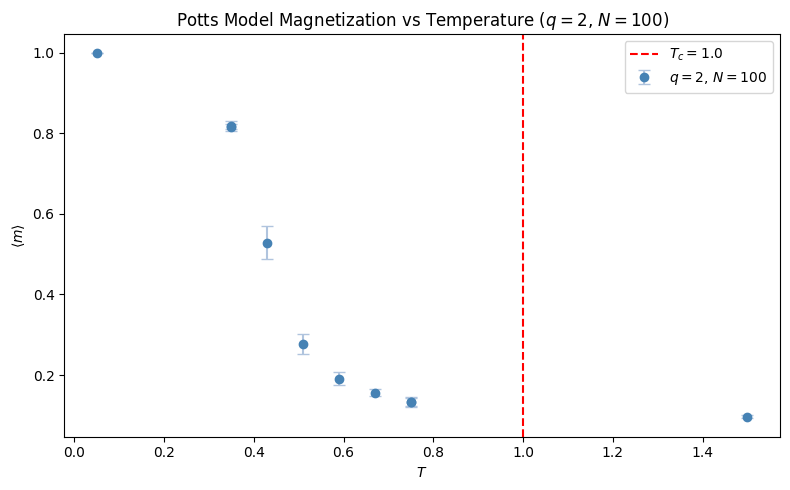

In [154]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    temperatures_potts,
    mean_magnetizations_potts,
    yerr=std_magnetizations_potts,
    fmt='o',
    capsize=4,
    color='steelblue',
    ecolor='lightsteelblue',
    label=f'$q = {q}$, $N = {N}$'
)
ax.axvline(1.0, color='red', linestyle='--', label='$T_c = 1.0$')
ax.set_xlabel('$T$')
ax.set_ylabel('$\\langle m \\rangle$')
ax.set_title(f'Potts Model Magnetization vs Temperature ($q = {q}$, $N = {N}$)')
ax.legend()
plt.tight_layout()

The Potts model for $q=2$ reduces to the Curie-Weiss model which has a theoretical critical temperature of $1.0$. Here analytically we see the transition happening closer to $0.45$. I attribute this most likely to finite-size effects. Again we observe the most variance closest to the transition point.

##### Step 4 - Experiments for $q=3$ and $q=4$

Experiments

In [151]:
q_values = [2, 3, 4]
mcs_max = 300
burn_in = 100
n_reps = 5

temperatures_potts = np.concatenate([
    np.linspace(0.05, 0.35, 2),
    np.linspace(0.35, 0.75, 6),
    np.linspace(0.75, 1.5, 2)
])

results_potts = {}

for q in q_values:
    print(f"Running q={q}...")
    mean_mags = []
    std_mags = []
    for T in temperatures_potts:
        rep_mags = []
        for _ in range(n_reps):
            E, m, spins = sample_configurations(
                N=100,
                q=q,
                T=T,
                mcs_max=mcs_max,
            )
            rep_mags.append(np.mean(m[burn_in:]))
        mean_mags.append(np.mean(rep_mags))
        std_mags.append(np.std(rep_mags))
    results_potts[q] = {
        'mean': np.array(mean_mags),
        'std': np.array(std_mags)
    }

Running q=2...
Running q=3...
Running q=4...


Plot

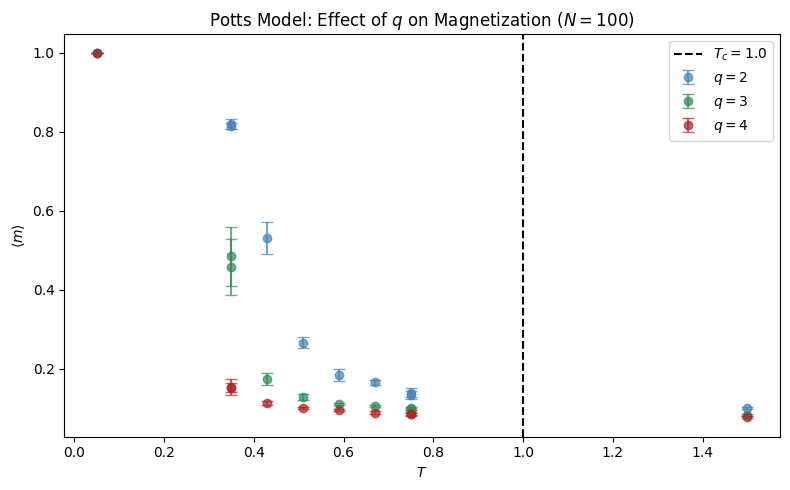

In [152]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['steelblue', 'seagreen', 'firebrick']

for q, color in zip(q_values, colors):
    ax.errorbar(
        temperatures_potts,
        results_potts[q]['mean'],
        yerr=results_potts[q]['std'],
        fmt='o',
        capsize=4,
        color=color,
        ecolor=color,
        alpha=0.7,
        label=f'$q = {q}$'
    )

ax.axvline(1.0, color='black', linestyle='--', label='$T_c = 1.0$')
ax.set_xlabel('$T$')
ax.set_ylabel('$\\langle m \\rangle$')
ax.set_title(f'Potts Model: Effect of $q$ on Magnetization ($N = 100$)')
ax.legend()
plt.tight_layout()

Here we observe that systems with higher q values have sharper phase trasitions and converge to lower average $m$ values. This makes sense as higher q values correspond to greater degrees of freedom which allows entropy to grow faster. As we add new spins, it give more and more possible high entropy configurations for the system to occupy.